# LSST footprint for a given night

Reuses the night-resolution, schedule-fetching, footprint-building and plotting
functions straight from [`eventsSelector.py`](src/LSST_GW/eventsSelector.py) (the
module behind the `lsst-gw-select-events` CLI) to plot the sky footprint LSST
covers on a given night -- with no GW event selection involved.

In [11]:
from pathlib import Path

import pandas as pd
from IPython.display import Image

from LSST_GW.eventsSelector import (
    resolve_night,
    fetch_lsst_pointings,
    build_night_footprint,
    plot_night_overview,
)

## 1) Pick a night

Set either `date_str` (a Chile/Santiago calendar date) or `mjd` (the night's
start MJD, unambiguous across timezones). Leave both `None` to default to the
next LSST night -- see `resolve_night`'s docstring for details.

In [12]:
date_str = None  # e.g. "2026-06-22"
mjd = 61213       # e.g. 61211.75 ; takes precedence over date_str if set

night_date, start_mjd = resolve_night(date_str, mjd)
print(f"Night of {night_date} (start MJD {start_mjd:.2f})")

Night of 2026-06-21 (start MJD 61213.00)


## 2) Fetch the planned LSST schedule

This always queries the obsloctap service live (regardless of any caching
elsewhere in the package), so it needs a working internet connection.

In [13]:
window_hours = 24.0
executed_only = False  # True restricts to pointings LSST actually executed (past nights only)

pointings = fetch_lsst_pointings(start_mjd, window_hours, executed_only)
print(f"{len(pointings)} scheduled pointings")
pointings.head()

1068 scheduled pointings


,t_planning,target_name,obs_id,obs_collection,s_ra,s_dec,s_fov,s_region,s_resolution,t_min,...,pol_xel,facility_name,instrument_name,t_plan_exptime,category,priority,execution_status,tracking_type,rubin_rot_sky_pos,rubin_nexp
0,61213.999832,lowdust,lowdust,,158.891502,-4.520639,3.5,,0.2,61213.992888,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,0,Scheduled,Sidereal,0.0,1
1,61213.999408,lowdust,lowdust,,156.049893,-3.660405,3.5,,0.2,61213.992464,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,0,Scheduled,Sidereal,0.0,1
2,61213.998985,lowdust,lowdust,,157.062010,-6.691295,3.5,,0.2,61213.992041,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,0,Scheduled,Sidereal,0.0,1
3,61213.998561,lowdust,lowdust,,160.003645,-7.515956,3.5,,0.2,61213.991616,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,0,Scheduled,Sidereal,0.0,1
4,61213.998137,lowdust,lowdust,,161.223844,-10.442947,3.5,,0.2,61213.991193,...,0,Rubin:Simonyi,LSSTCam,30.0,Fixed,0,Scheduled,Sidereal,0.0,1


## 3) Merge pointings into a single footprint geometry

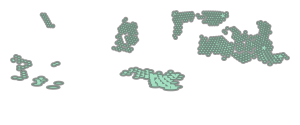

In [14]:
footprint = build_night_footprint(pointings)
footprint  # shapely geometries render as an SVG preview in Jupyter

## 4) Plot it

`plot_night_overview` normally overlays selected GW events on top of the
footprint, but `ranking`/`events_by_id` are both optional in practice -- an
empty ranking just skips the overlay, leaving the footprint-only Mollweide
plot below. The figure is saved to disk and reopened here for display since
the function closes its own figure after saving.

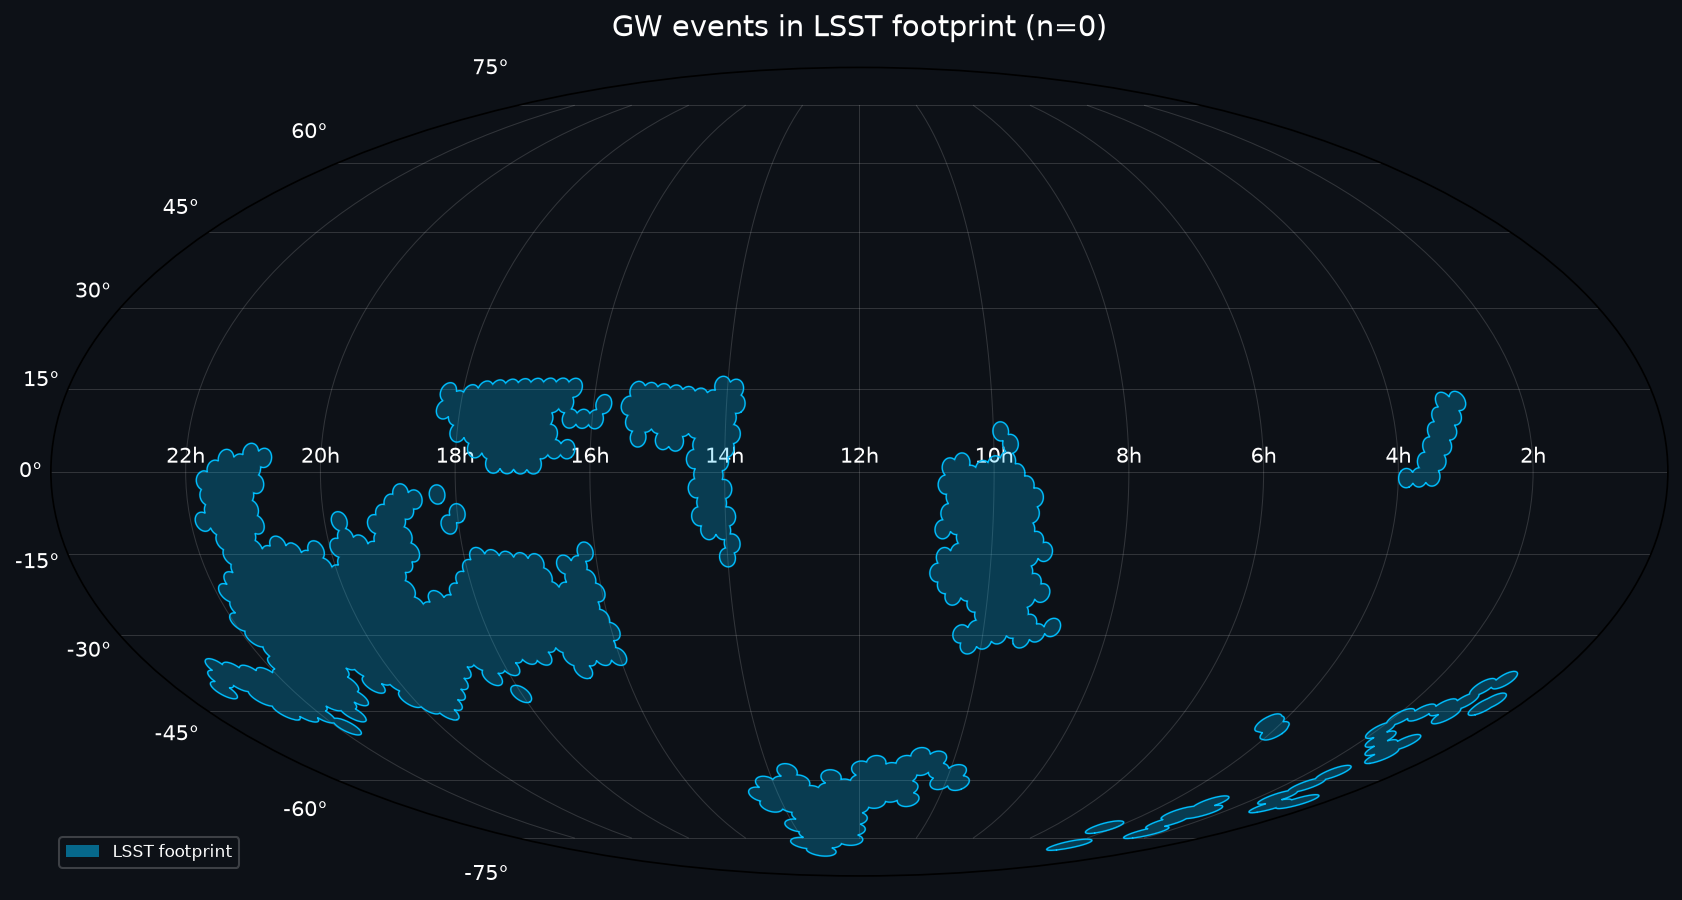

In [15]:
output_dir = Path.cwd() / "output" / "footprint_notebook"
fig_path = plot_night_overview(footprint, pd.DataFrame(), {}, output_dir)
Image(filename=fig_path)